# Modèle de prédiction de l'âge des arbres


Objectif : prédire `age_estim` à partir des caractéristiques morphologiques, du stade de développement et de l'espèce de l'arbre.

## 1. Imports

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Affichage plus lisible des tableaux
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

## 2. Chargement des données

In [2]:
from google.colab import files
uploaded = files.upload()

Saving export_IA.csv to export_IA.csv


In [3]:
# Lecture du fichier nettoyé issu du projet Big Data
df = pd.read_csv('export_IA.csv')

print('Dimensions du fichier complet :', df.shape)
df.head()

Dimensions du fichier complet : (11374, 20)


,X,Y,OBJECTID,clc_quartier,clc_secteur,id_arbre,haut_tot,haut_tronc,tronc_diam,fk_arb_etat,fk_stadedev,fk_pied,fk_situation,dte_plantation,age_estim,nomfrancais,GlobalID,feuillage,remarquable,abattre
0,1.720320e+06,8.294619e+06,1,quartier du centre ville,boulevard richelieu,24,0.0,0.0,0.0,supprimé,ras,ras,Alignement,date inconnu,0.0,ras,{476EB2CE-1FD4-4F89-8162-79D75651225A},inconnu,0,1
1,1.720898e+06,8.293531e+06,2,quartier du centre ville,boulevard léon blum,24,0.0,0.0,0.0,abattu,ras,ras,Alignement,date inconnu,0.0,ras,{B5A9F630-92C5-4B8A-A934-0CABDA46085E},inconnu,0,1
2,1.720894e+06,8.293542e+06,3,quartier du centre ville,boulevard léon blum,53,0.0,0.0,0.0,supprimé,ras,ras,Alignement,date inconnu,0.0,ras,{F5914EAD-05CD-4ADF-A7C9-55EFF91B2ABE},inconnu,0,1
3,1.720902e+06,8.293545e+06,4,quartier du centre ville,boulevard léon blum,54,0.0,0.0,0.0,supprimé,ras,ras,Alignement,date inconnu,0.0,ras,{41168E06-B7C0-43CD-B8FE-7495B6E93AB5},inconnu,0,1
4,1.721089e+06,8.293619e+06,5,quartier du centre ville,boulevard léon blum,63,0.0,0.0,0.0,abattu,ras,ras,Alignement,date inconnu,0.0,ras,{4F0E4B12-4612-4F61-9911-43684831FD7D},inconnu,0,1


## 3. Sélection des variables

Variables numériques :
- `tronc_diam` : diamètre du tronc
- `haut_tot` : hauteur totale
- `haut_tronc` : hauteur du tronc

Variables catégorielles :
- `fk_stadedev` : stade de développement
- `nomfrancais` : espèce / nom français de l'arbre

Cible à prédire :
- `age_estim`

In [4]:
features_num = ['tronc_diam', 'haut_tot', 'haut_tronc']
features_cat = ['fk_stadedev', 'nomfrancais']
target = 'age_estim'

colonnes_utiles = features_num + features_cat + [target]

# Suppression des lignes incomplètes sur les colonnes utiles
data = df[colonnes_utiles].dropna().copy()

print('Dimensions après sélection/nettoyage :', data.shape)
print('Colonnes utilisées :', colonnes_utiles)
data.head()

Dimensions après sélection/nettoyage : (11374, 6)
Colonnes utilisées : ['tronc_diam', 'haut_tot', 'haut_tronc', 'fk_stadedev', 'nomfrancais', 'age_estim']


,tronc_diam,haut_tot,haut_tronc,fk_stadedev,nomfrancais,age_estim
0,0.0,0.0,0.0,ras,ras,0.0
1,0.0,0.0,0.0,ras,ras,0.0
2,0.0,0.0,0.0,ras,ras,0.0
3,0.0,0.0,0.0,ras,ras,0.0
4,0.0,0.0,0.0,ras,ras,0.0


## 4. Analyse rapide des données utilisées

In [5]:
print('Résumé des variables numériques :')
display(data[features_num + [target]].describe().round(2))

print('Stades de développement :')
display(data['fk_stadedev'].value_counts())

print('Nombre d’espèces différentes :', data['nomfrancais'].nunique())

Résumé des variables numériques :


,tronc_diam,haut_tot,haut_tronc,age_estim
count,11374.00,11374.00,11374.00,11374.00
mean,94.15,10.19,2.61,30.83
std,56.80,5.79,1.66,19.06
min,0.00,0.00,0.00,0.00
25%,48.00,6.00,2.00,15.00
50%,90.00,8.00,2.00,30.00
75%,130.00,14.00,3.00,40.00
max,443.00,37.00,15.00,130.00


Stades de développement :


,count
fk_stadedev,
adulte,6447
jeune,4615
ras,194
vieux,65
senescent,53


Nombre d’espèces différentes : 241


## 5. Séparation entraînement / test

Le dataset est séparé en deux parties :
- 80 % pour l'entraînement
- 20 % pour le test

Le jeu de test sert uniquement à évaluer les performances finales.

In [6]:
X = data[features_num + features_cat]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Taille X_train :', X_train.shape)
print('Taille X_test  :', X_test.shape)

Taille X_train : (9099, 5)
Taille X_test  : (2275, 5)


## 6. Pipeline de prétraitement

Le pipeline applique :
- une standardisation sur les variables numériques ;
- un encodage One-Hot sur les variables catégorielles.

Ce prétraitement est inclus dans chaque modèle afin d'éviter les erreurs entre l'entraînement et la prédiction.

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
    ]
)

## 7. Modèle 1 — Régression linéaire enrichie

La régression linéaire est utilisée comme modèle de référence. Elle est simple, interprétable et permet d'évaluer une relation linéaire entre les variables et l'âge.

In [9]:
modele_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regression', LinearRegression())
])

modele_lr.fit(X_train, y_train)
y_pred_lr = modele_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print('=== Régression linéaire ===')
print('RMSE :', round(rmse_lr, 2))
print('MAE  :', round(mae_lr, 2))
print('R²   :', round(r2_lr, 4))

=== Régression linéaire ===
RMSE : 10.02
MAE  : 6.96
R²   : 0.7385


## 8. Modèle 2 — Random Forest Regressor

Le Random Forest est testé comme modèle non linéaire. Il repose sur un ensemble d'arbres de décision et permet de capturer des relations plus complexes que la régression linéaire.

In [10]:
modele_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regression', RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

modele_rf.fit(X_train, y_train)
y_pred_rf = modele_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('=== Random Forest Regressor ===')
print('RMSE :', round(rmse_rf, 2))
print('MAE  :', round(mae_rf, 2))
print('R²   :', round(r2_rf, 4))

=== Random Forest Regressor ===
RMSE : 8.25
MAE  : 4.74
R²   : 0.823


## 9. Comparaison des modèles

Les deux modèles sont comparés avec trois métriques :
- **RMSE** : erreur quadratique moyenne, pénalise davantage les grosses erreurs ;
- **MAE** : erreur moyenne absolue, interprétable en années ;
- **R²** : part de la variance expliquée par le modèle.

In [15]:
comparaison = pd.DataFrame({
    'Modèle': ['Régression linéaire', 'Random Forest Regressor'],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE': [mae_lr, mae_rf],
    'R²': [r2_lr, r2_rf]
})

comparaison = comparaison.round({'RMSE': 2, 'MAE': 2, 'R²': 4})
display(comparaison)

,Modèle,RMSE,MAE,R²
0,Régression linéaire,10.02,6.96,0.7385
1,Random Forest Regressor,8.25,4.74,0.8230


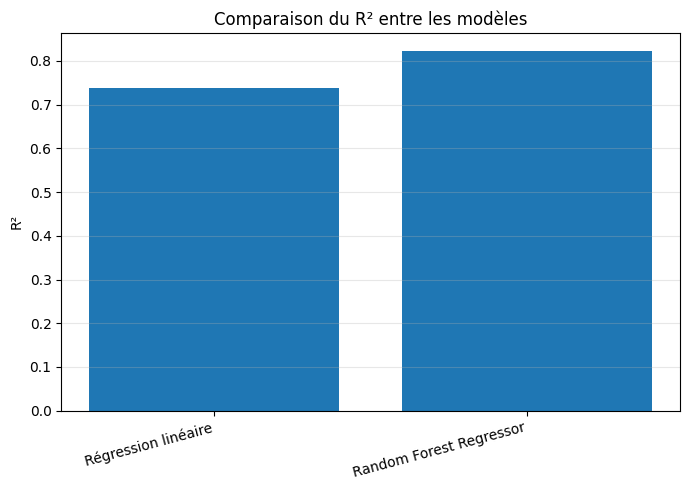

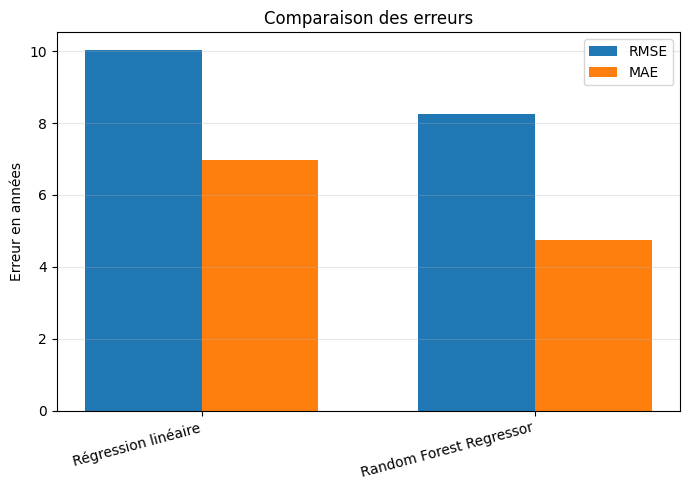

In [16]:
# Graphe comparatif du R²
plt.figure(figsize=(7, 5))
plt.bar(comparaison['Modèle'], comparaison['R²'])
plt.ylabel('R²')
plt.title('Comparaison du R² entre les modèles')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Graphe comparatif des erreurs
plt.figure(figsize=(7, 5))
x = np.arange(len(comparaison['Modèle']))
width = 0.35
plt.bar(x - width/2, comparaison['RMSE'], width, label='RMSE')
plt.bar(x + width/2, comparaison['MAE'], width, label='MAE')
plt.ylabel('Erreur en années')
plt.title('Comparaison des erreurs')
plt.xticks(x, comparaison['Modèle'], rotation=15, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Choix du modèle final

Le modèle final est sélectionné automatiquement selon le meilleur R² sur le jeu de test. En cas de performances proches, la régression linéaire reste plus interprétable ; le Random Forest est retenu s'il apporte un gain clair.

In [13]:
if r2_rf > r2_lr:
    modele_final = modele_rf
    y_pred_final = y_pred_rf
    nom_modele_final = 'Random Forest Regressor'
    rmse_final, mae_final, r2_final = rmse_rf, mae_rf, r2_rf
else:
    modele_final = modele_lr
    y_pred_final = y_pred_lr
    nom_modele_final = 'Régression linéaire'
    rmse_final, mae_final, r2_final = rmse_lr, mae_lr, r2_lr

print('Modèle final retenu :', nom_modele_final)
print('RMSE :', round(rmse_final, 2))
print('MAE  :', round(mae_final, 2))
print('R²   :', round(r2_final, 4))

Modèle final retenu : Random Forest Regressor
RMSE : 8.25
MAE  : 4.74
R²   : 0.823


## 11. Graphes du modèle final

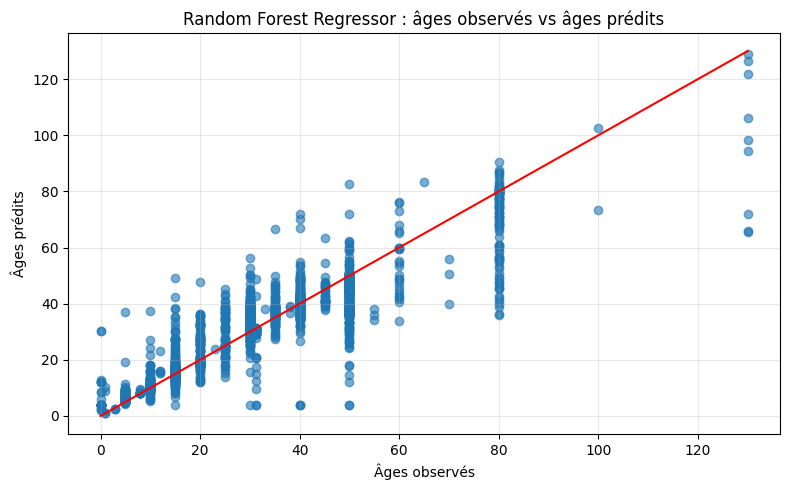

In [17]:
# Observé vs prédit
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_final, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.xlabel('Âges observés')
plt.ylabel('Âges prédits')
plt.title(f'{nom_modele_final} : âges observés vs âges prédits')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

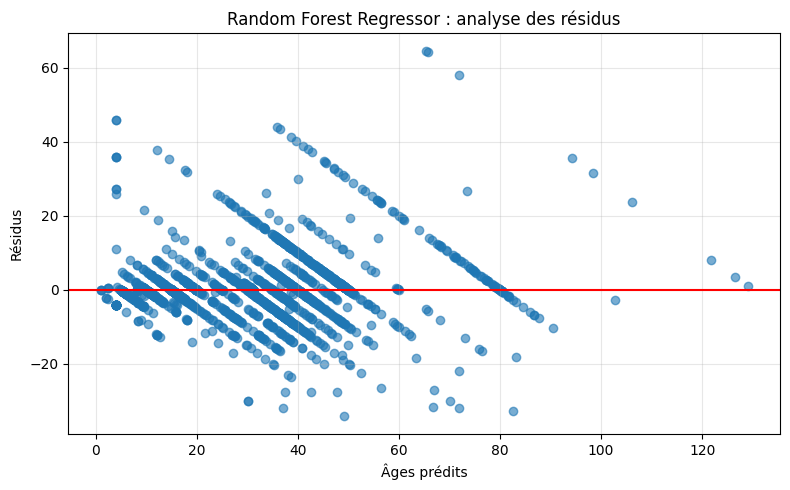

In [18]:
# Résidus vs prédictions
residus_final = y_test - y_pred_final

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_final, residus_final, alpha=0.6)
plt.axhline(0, color='red')
plt.xlabel('Âges prédits')
plt.ylabel('Résidus')
plt.title(f'{nom_modele_final} : analyse des résidus')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

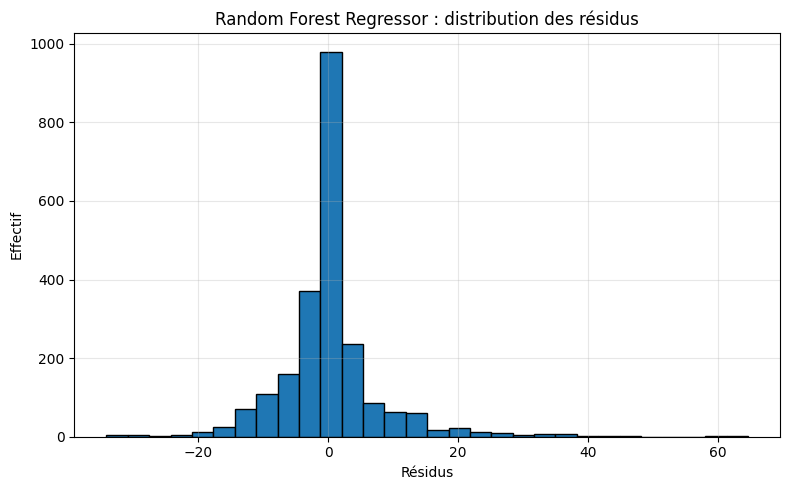

In [19]:
# Distribution des résidus
plt.figure(figsize=(8, 5))
plt.hist(residus_final, bins=30, edgecolor='black')
plt.xlabel('Résidus')
plt.ylabel('Effectif')
plt.title(f'{nom_modele_final} : distribution des résidus')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Importance des variables pour Random Forest

Ce graphe permet d'identifier les variables qui ont le plus contribué aux prédictions du Random Forest.

,variable,importance
4,cat__fk_stadedev_jeune,0.433379
0,num__tronc_diam,0.234079
2,num__haut_tronc,0.138490
1,num__haut_tot,0.056556
3,cat__fk_stadedev_adulte,0.014636
145,cat__nomfrancais_pinnignig,0.012836
5,cat__fk_stadedev_ras,0.010889
225,cat__nomfrancais_tilcor,0.008490
202,cat__nomfrancais_ras,0.007315
148,cat__nomfrancais_plaace,0.007149


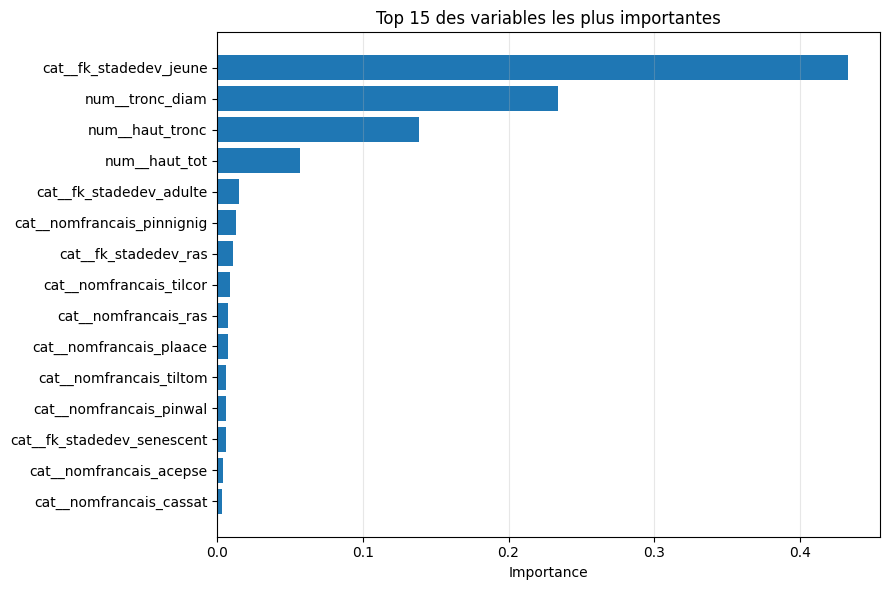

In [20]:
if nom_modele_final == 'Random Forest Regressor':
    feature_names = modele_final.named_steps['preprocessor'].get_feature_names_out()
    importances = modele_final.named_steps['regression'].feature_importances_

    df_importances = pd.DataFrame({
        'variable': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)

    display(df_importances.head(15))

    plt.figure(figsize=(9, 6))
    top = df_importances.head(15).iloc[::-1]
    plt.barh(top['variable'], top['importance'])
    plt.xlabel('Importance')
    plt.title('Top 15 des variables les plus importantes')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Le modèle final est linéaire : importance Random Forest non affichée.')

## 13. Sauvegarde du modèle final

Le pipeline complet est sauvegardé : il contient à la fois le prétraitement et le modèle. Cela permet de réutiliser le modèle sans refaire l'entraînement.

In [21]:
os.makedirs('resultats_ia', exist_ok=True)

joblib.dump(modele_final, 'resultats_ia/modele_final_prediction_age.pkl')
comparaison.to_csv('resultats_ia/comparaison_modeles.csv', index=False)

print('Modèle final sauvegardé dans : resultats_ia/modele_final_prediction_age.pkl')
print('Tableau de comparaison sauvegardé dans : resultats_ia/comparaison_modeles.csv')

Modèle final sauvegardé dans : resultats_ia/modele_final_prediction_age.pkl
Tableau de comparaison sauvegardé dans : resultats_ia/comparaison_modeles.csv


## 14. Fonction finale de prédiction

Cette fonction simule l'utilisation du modèle dans une application. Elle prend en entrée les caractéristiques d'un arbre et retourne l'âge prédit.

In [22]:
def predire_age_arbre(tronc_diam, haut_tot, haut_tronc, fk_stadedev, nomfrancais, modele):
    nouvel_arbre = pd.DataFrame([{
        'tronc_diam': tronc_diam,
        'haut_tot': haut_tot,
        'haut_tronc': haut_tronc,
        'fk_stadedev': fk_stadedev,
        'nomfrancais': nomfrancais
    }])

    age_predit = modele.predict(nouvel_arbre)[0]
    return age_predit

## 15. Test de la fonction de prédiction

Avant de tester la fonction, vérifier les valeurs exactes disponibles pour `fk_stadedev` et `nomfrancais`.

In [23]:
print('Valeurs possibles pour fk_stadedev :')
print(data['fk_stadedev'].unique())

print('Exemples de valeurs pour nomfrancais :')
print(data['nomfrancais'].unique()[:20])

Valeurs possibles pour fk_stadedev :
['ras' 'jeune' 'adulte' 'senescent' 'vieux']
Exemples de valeurs pour nomfrancais :
['ras' 'querub' 'pinnignig' 'acepse' 'acepla' 'salbab' 'tilcor' 'tiltom'
 'plaace' 'catbig' 'thupliatr' 'acesac' 'aeship' 'pruser' 'carbetfas'
 'mal' 'popnigita' 'poptre' 'popcan' 'aceneg']


In [24]:
# Exemple à adapter avec des valeurs réelles
age_pred = predire_age_arbre(
    tronc_diam=40,
    haut_tot=18,
    haut_tronc=6,
    fk_stadedev=data['fk_stadedev'].iloc[0],
    nomfrancais=data['nomfrancais'].iloc[0],
    modele=modele_final
)

print('Âge prédit :', round(age_pred, 1), 'ans')

Âge prédit : 19.4 ans


## 16. Export des prédictions du jeu de test

Ce fichier peut être utilisé pour vérifier les erreurs de prédiction.

In [25]:
predictions_test = X_test.copy()
predictions_test['age_observe'] = y_test.values
predictions_test['age_predit'] = y_pred_final
predictions_test['residu'] = predictions_test['age_observe'] - predictions_test['age_predit']

predictions_test.to_csv('resultats_ia/predictions_test.csv', index=False)
predictions_test.head()

,tronc_diam,haut_tot,haut_tronc,fk_stadedev,nomfrancais,age_observe,age_predit,residu
251,175.0,25.0,7.0,adulte,acepla,80.0,67.483508,12.516492
6070,65.0,16.0,5.0,adulte,popcan,30.0,31.501666,-1.501666
6596,120.0,14.0,2.0,adulte,acepse,35.0,37.037346,-2.037346
5426,115.0,14.0,2.0,adulte,tilcor,40.0,37.058774,2.941226
11119,77.0,9.0,2.0,jeune,alncor,10.0,14.402489,-4.402489
